# EDA - Distribuciones, Correlaciones y Modelo lineal
En este primer notebook, el objetivo fue realizar una exploración inicial de los datos, graficando las distribuciones de todas las variables (numéricas y categóricas), en busca de detectar outliers, valores faltantes, distribuciones llamativas, etc.

Luego, se optó por orientar el análisis hacia el cálculo de correlaciones de Spearman, con sus respectivos p-valores.

Más tarde, ya con un subset de variables elegido, se aplicaron varios modelos lineales con OLS, a razón de explorar la relación entre las covariables y el índice de performance hospitalario.

## Conexión a la base de datos

In [1]:
# Conexión a la base de datos utilizando SQLAlchemy y psycopg2
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_CONFIG = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "dbname": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD")
}

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

engine = get_engine()

## Lectura del dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Lectura del dataset desde la base de datos
query = "SELECT * FROM hospital_performance_final"

df = pd.read_sql(query, engine)

# Configuración que permite mostrar todas las columnas
pd.set_option('display.max_columns', None)

df.head()

,hospital_id,hospital_name,sector,city,province,hospital_type,year,total_beds,icu_beds,operation_theatres,emergency_department,diagnostic_labs,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,insurance_accepted,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,ambulance_available,telemedicine_service,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,quality_score,efficiency_score,cost_score,hpi
0,H10000,Hospital_TSDGA,Public,Sialkot,Punjab,Specialized,2024,1432,49,6,Yes,No,5.3,331,120,799,269,0.001418,2367,775,260,3.2,692,976.0,621.0,39060.0,29429077.0,Yes,5.1,2.24,3.34,8.49,31,8.2,Yes,No,49.0,2392.833333,0,0.342,0.826,0.990,0.617
1,H10001,Hospital_VAXQQ,Private,Quetta,Balochistan,General,2023,905,29,4,No,No,8.5,271,36,381,38,0.001547,642,1488,101,3.7,61,3614.0,2516.0,31821.0,0.0,Yes,7.3,0.66,6.70,7.76,5,29.1,No,Yes,15.0,691.600000,0,0.443,0.871,0.937,0.670
2,H10002,Hospital_XABQD,Public,Kasur,Punjab,Specialized,2024,456,141,20,Yes,Yes,6.8,135,90,83,212,0.000927,992,928,331,4.6,16,6865.0,252.0,45706.0,38516209.0,No,7.9,4.71,4.07,7.39,179,3.7,Yes,No,68.0,1022.933333,0,0.362,0.321,0.871,0.452
3,H10003,Hospital_AYNGM,Public,Sheikhupura,Punjab,Specialized,2023,890,121,1,No,Yes,7.5,216,101,115,253,0.001625,921,170,162,4.7,257,12006.0,276.0,75900.0,35923243.0,No,7.5,3.95,5.32,9.41,116,39.1,Yes,Yes,45.0,926.666667,0,0.278,0.495,0.767,0.441
4,H10004,Hospital_ZRAVI,Public,Sheikhupura,Punjab,Specialized,2022,978,72,17,Yes,Yes,7.4,381,43,474,65,0.000704,1555,591,283,7.7,690,875.0,530.0,73349.0,32512196.0,Yes,9.1,4.88,0.96,3.15,99,18.4,Yes,No,15.0,1574.700000,0,0.657,0.367,0.992,0.637


In [3]:
# Información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   hospital_id                 5500 non-null   object 
 1   hospital_name               5500 non-null   object 
 2   sector                      5500 non-null   object 
 3   city                        5500 non-null   object 
 4   province                    5500 non-null   object 
 5   hospital_type               5500 non-null   object 
 6   year                        5500 non-null   int64  
 7   total_beds                  5500 non-null   int64  
 8   icu_beds                    5500 non-null   int64  
 9   operation_theatres          5500 non-null   int64  
 10  emergency_department        5500 non-null   object 
 11  diagnostic_labs             5500 non-null   object 
 12  medical_equipment_score     5500 non-null   float64
 13  total_doctors               5500 

Además de las 36 variables iniciales con las que cuenta el dataset, optamos por fabricar algunos features que, creímos, le podrían aportar valor al análisis.

Los mismos son:
* estimated_daily_load: daily_outpatients + monthly_admissions / 30. Estima la cantidad de gente que pasa por o se encuentra en el hospital al día.
* icu_inconsistency_flag: Variable binaria, 1 cuando la cantidad icu_beds supera a total_beds, 0 en caso contrario. Se marcó estos casos como 'inconsistentes', aunque no fue considerado en el análisis.

Los siguientes son índices que normalizan e invierten (en los casos que corresponda) las variables que utilizan:
* quality_score (Q): (mortality_rate + infection_rate + readmission_rate + satisfaction_score) / 4
* efficiency_score (E): (waiting_time + length_of_stay) / 2
* cost_score (C): avg_treatment_cost
* HPI: 0.5Q + 0.3E + 0.2C

## Distribuciones

### Variables Categóricas

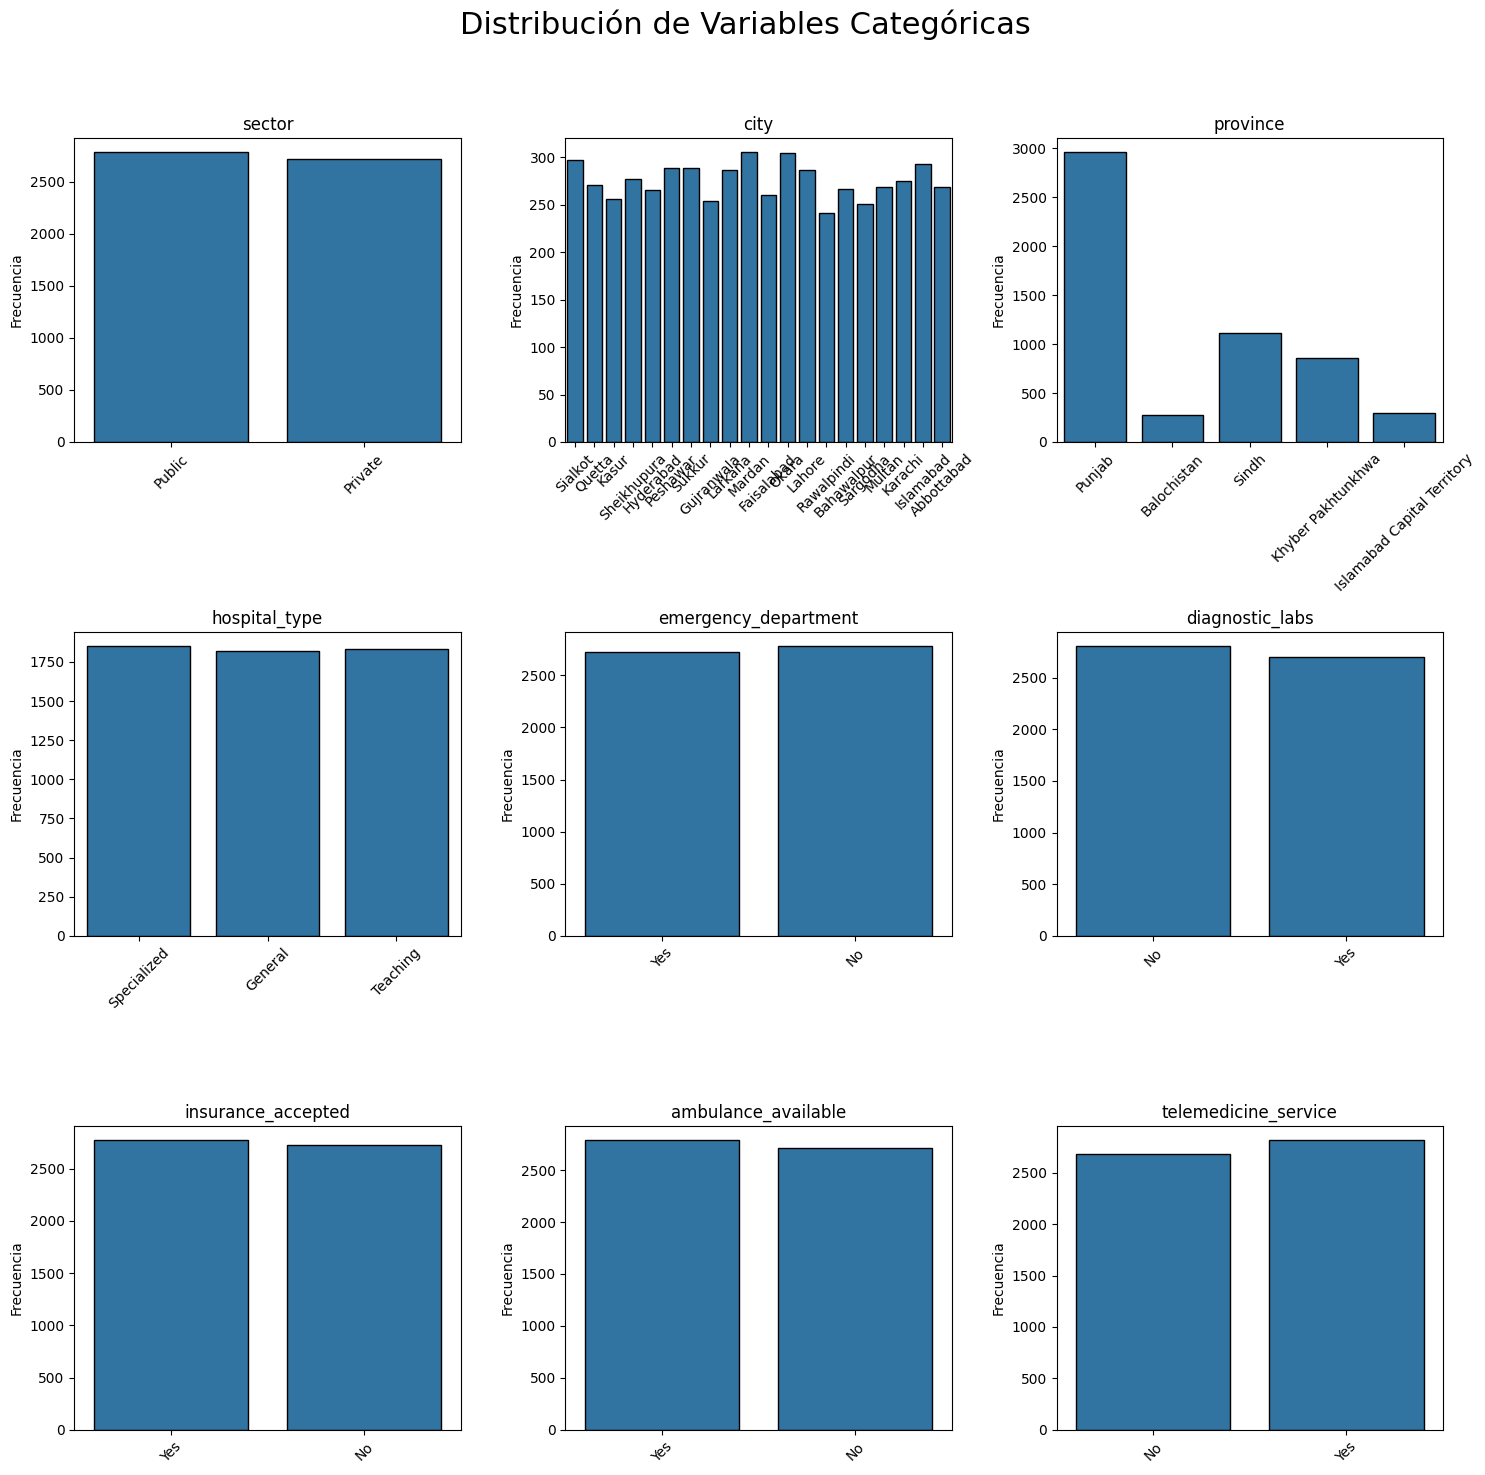

In [4]:
# seleccionar variables categóricas
cat_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].nunique() < 30  # filtro por cantidad de categorías
]

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # simplifica indexado

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    sns.countplot(
        data=df,
        x=col,
        dodge=False,
        edgecolor="black",
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)

# eliminar ejes vacíos (si sobran)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de Variables Categóricas", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # ← deja espacio arriba
plt.show()

### Variables Enteras

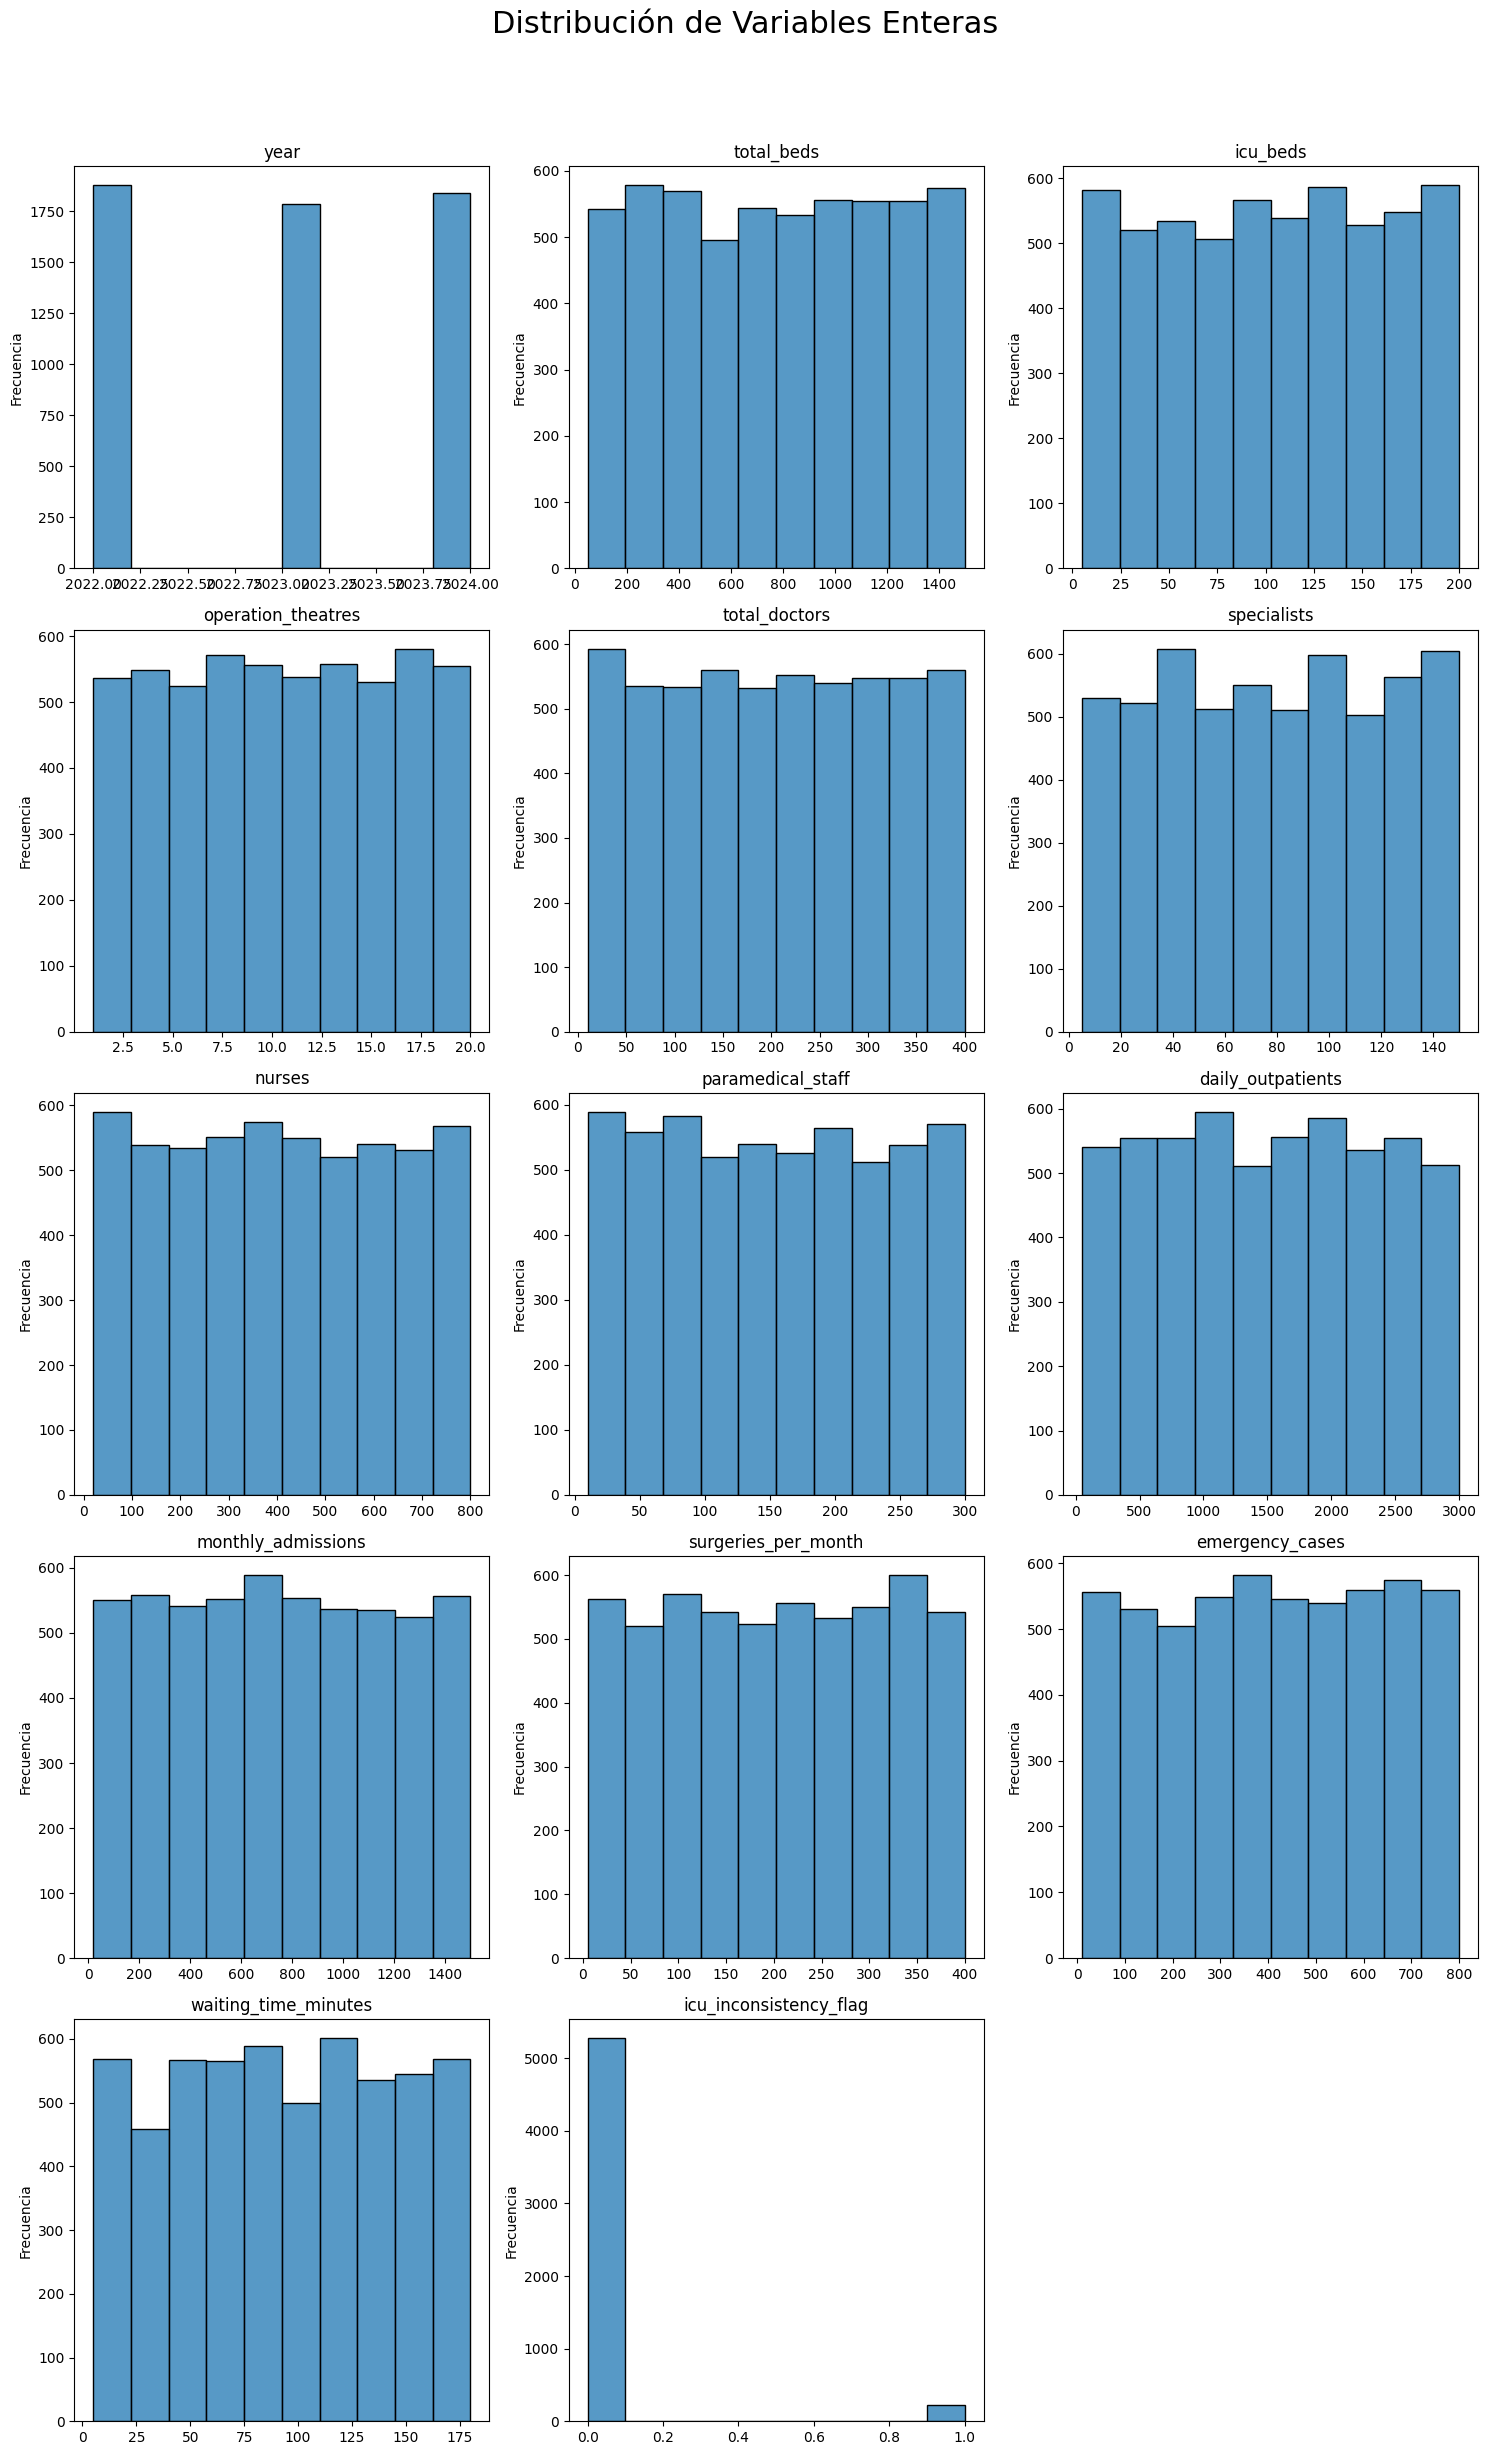

In [5]:
# seleccionar variables enteras
int_cols = df.select_dtypes(include=["int64", "int32"]).columns

n_cols = 3
n_rows = math.ceil(len(int_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):
    ax = axes[i]
    data = df[col].dropna()
    
    sns.histplot(data, bins=10, edgecolor="black", ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de Variables Enteras", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Variables Continuas

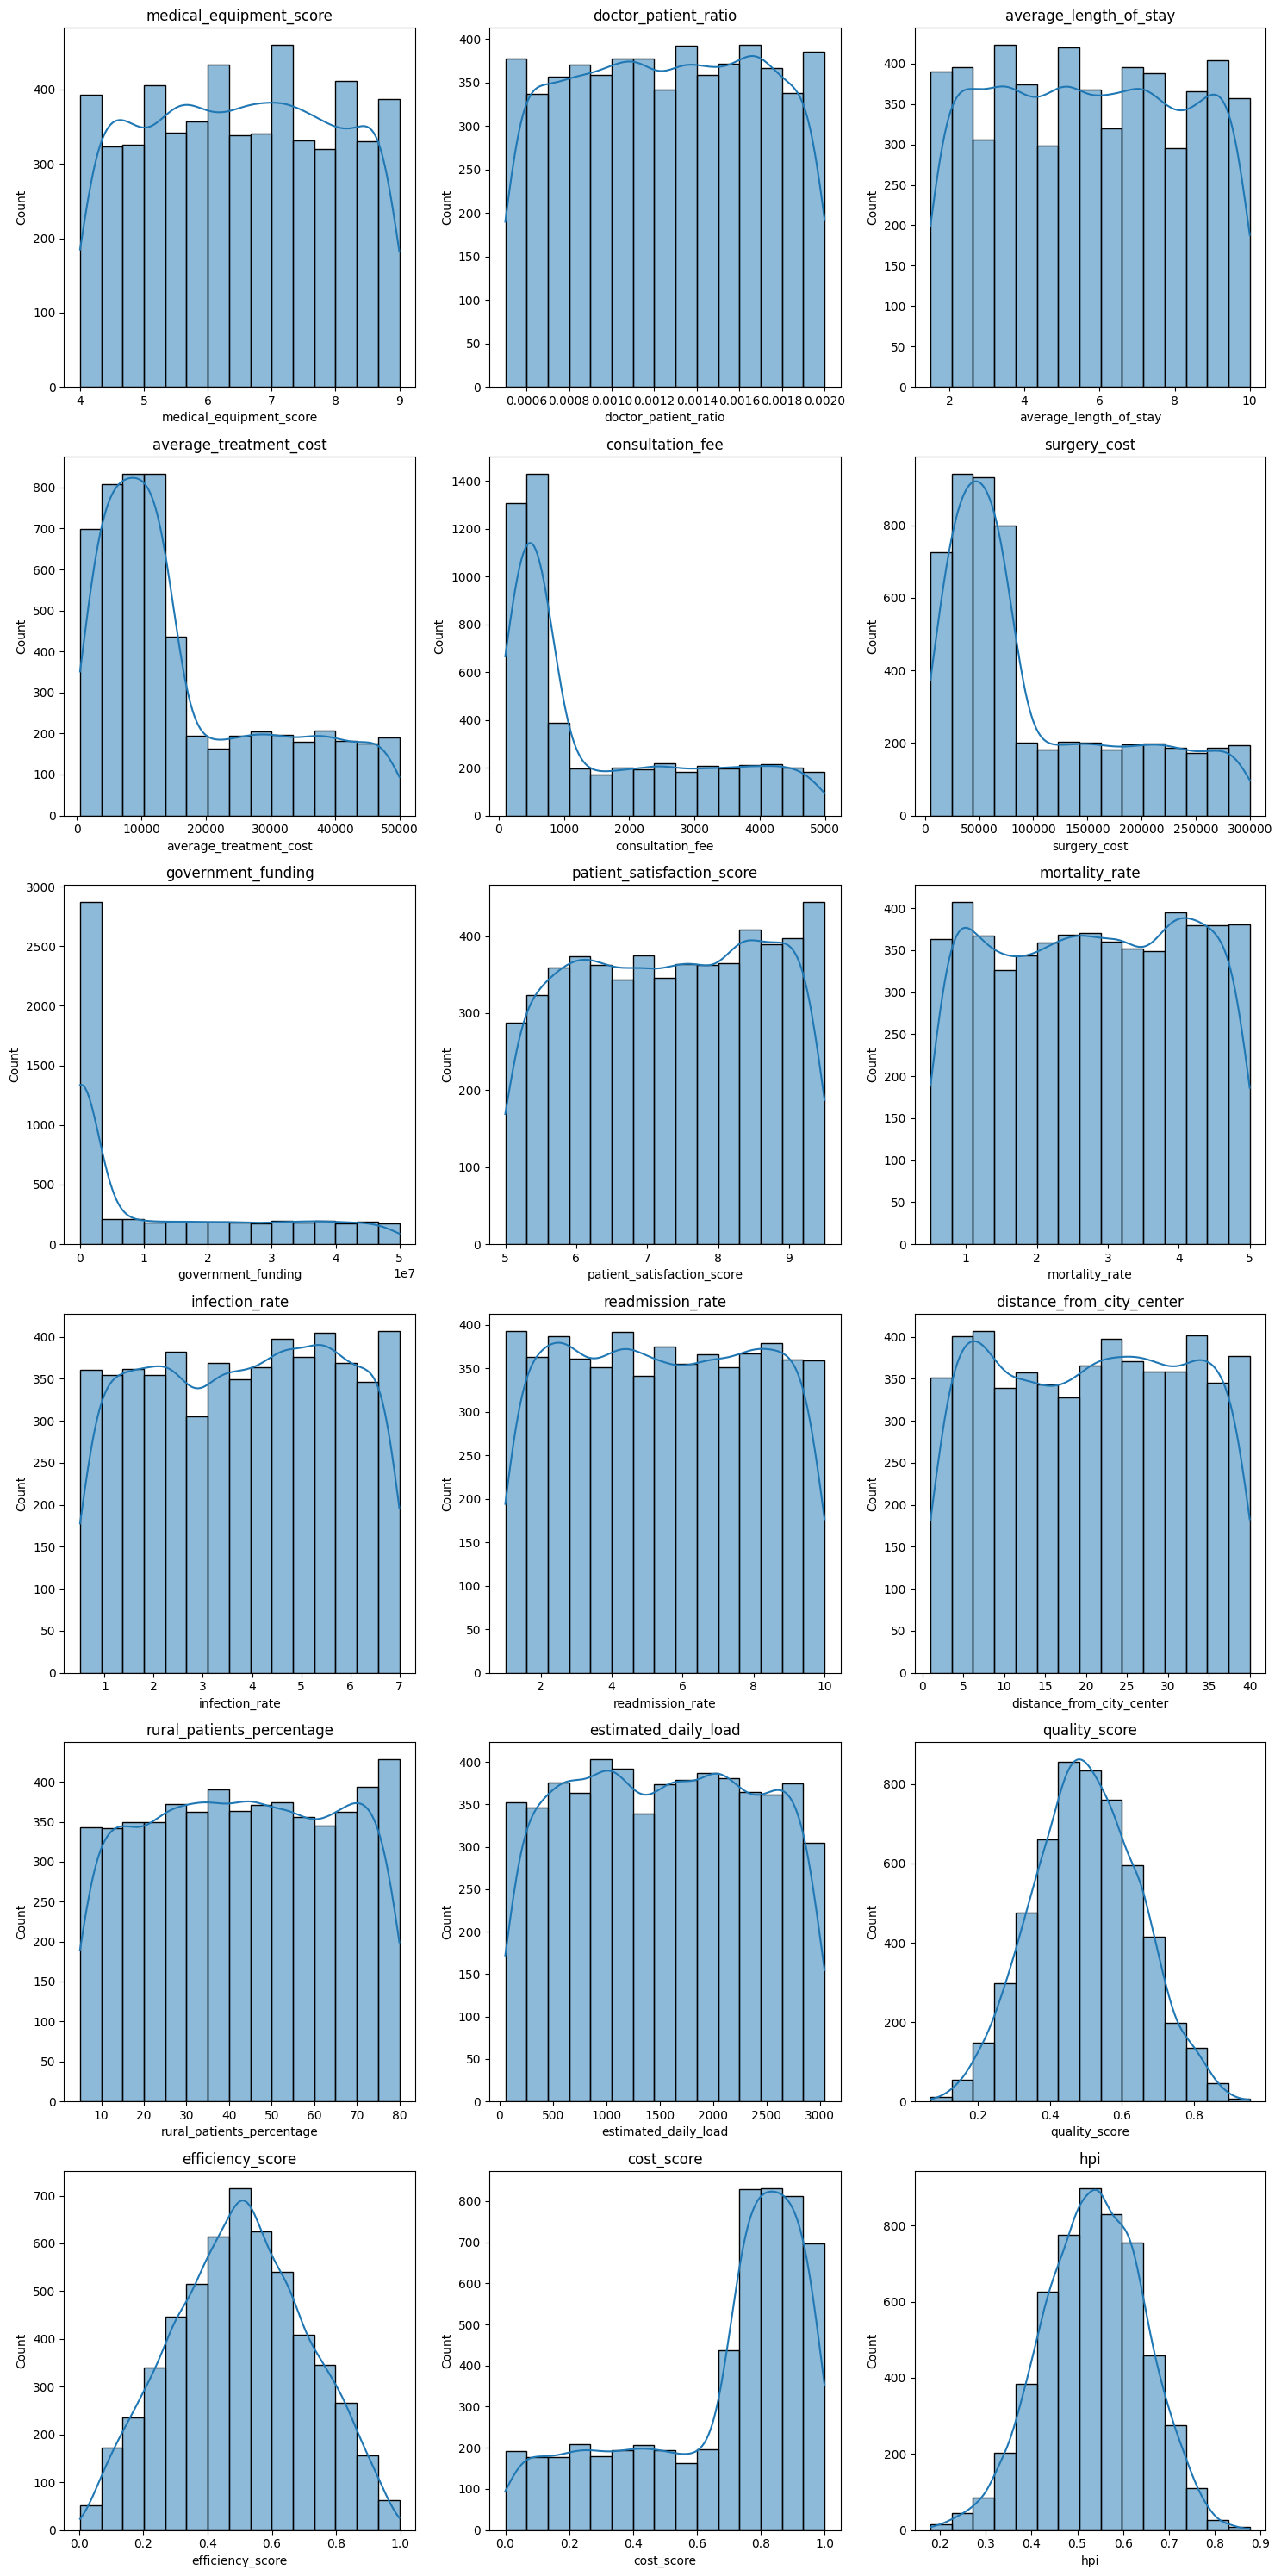

In [6]:
# seleccionar variables continuas (float)
float_cols = df.select_dtypes(include=["float64", "float32"]).columns

n_cols = 3  # ajustable
n_rows = math.ceil(len(float_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    ax = axes[i]
    
    data = df[col].dropna()

    sns.histplot(data, bins=15, edgecolor="black", kde=True, ax=ax)
    
    ax.set_title(col)

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Correlaciones Spearman

### Creación de variables binarias 1|0
A partir de variables categóricas.

In [7]:
# Creación de variables binarias a partir de columnas categóricas
df['sector_bin'] = df['sector'].map({'Public': 1, 'Private': 0})

# Identificar columnas con valores "yes"/"no" y crear variables binarias
yes_no_cols = []
for col in df.select_dtypes(include="object").columns:
    vals = df[col].dropna().astype(str).str.strip().str.lower().unique()
    if set(vals).issubset({"yes", "no"}):
        yes_no_cols.append(col)

for col in yes_no_cols:
    df[f"{col}_bin"] = df[col].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})

df[[*yes_no_cols, *[f"{col}_bin" for col in yes_no_cols]]].head()

,emergency_department,diagnostic_labs,insurance_accepted,ambulance_available,telemedicine_service,emergency_department_bin,diagnostic_labs_bin,insurance_accepted_bin,ambulance_available_bin,telemedicine_service_bin
0,Yes,No,Yes,Yes,No,1,0,1,1,0
1,No,No,Yes,No,Yes,0,0,1,0,1
2,Yes,Yes,No,Yes,No,1,1,0,1,0
3,No,Yes,No,Yes,Yes,0,1,0,1,1
4,Yes,Yes,Yes,Yes,No,1,1,1,1,0


A tener en cuenta: Yes = 1, No = 0. Public = 1, Private = 0

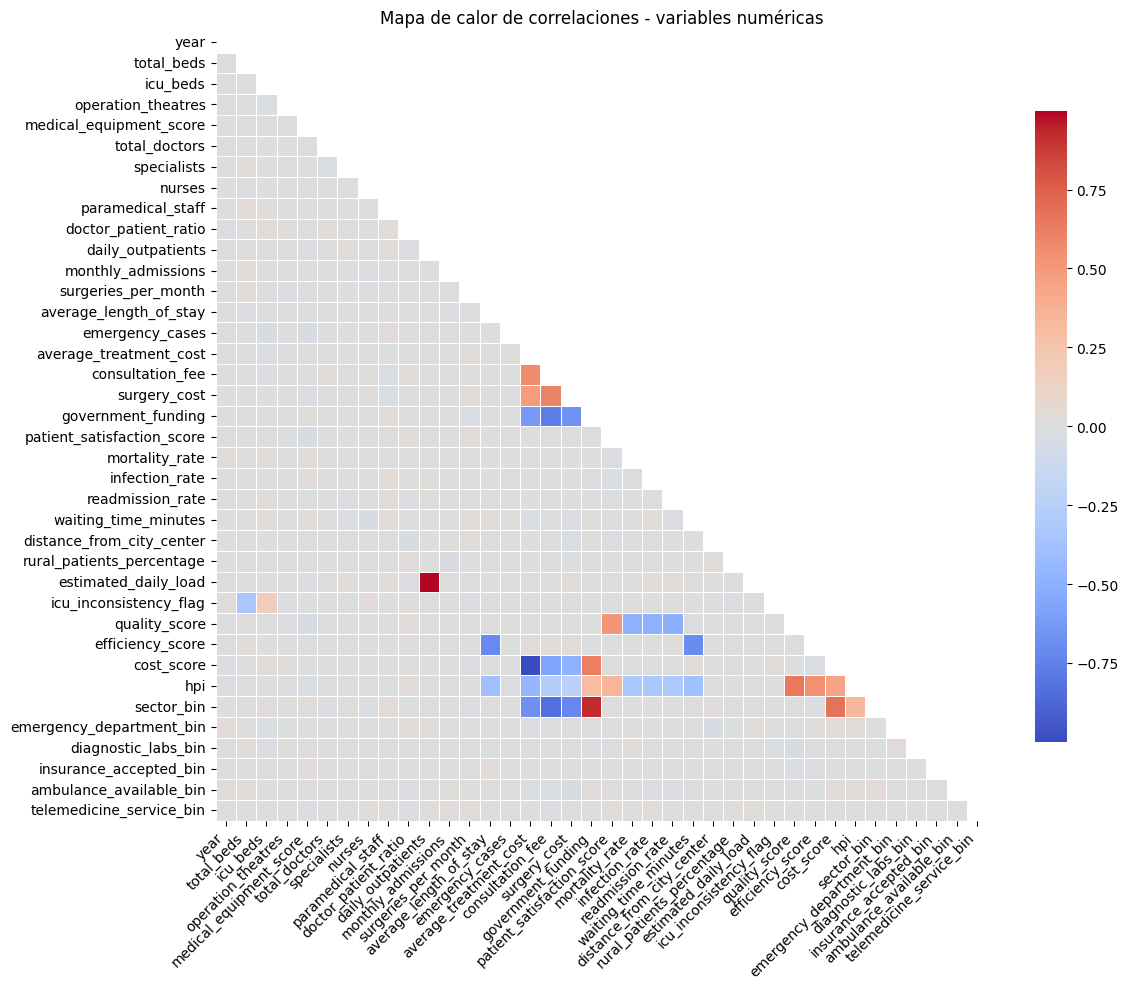

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns

corr_matrix = df[num_cols].corr(method='spearman')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Mapa de calor de correlaciones - variables numéricas")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Exclusión de las variables utilizadas para la construcción del índice

In [9]:
hpi_vars = ["hpi", 'mortality_rate', 'infection_rate', 'readmission_rate', 
            'patient_satisfaction_score', 'waiting_time_minutes', 
            'average_length_of_stay', 'average_treatment_cost', 
            'quality_score', 'efficiency_score', 'cost_score']

In [10]:
target_col = 'hpi'
exclude_vars = hpi_vars

### Test de correlaciones Spearman

In [11]:
from scipy.stats import spearmanr

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(exclude_vars)

results = []
for col in numeric_cols:
    corr, p_value = spearmanr(df[col], df[target_col])
    results.append({
        "variable": col,
        "spearman_corr": corr,
        "p_value": p_value,
        "significant": p_value < 0.1
    })

spearman_top = (
    pd.DataFrame(results)
      .sort_values(by="spearman_corr", key=lambda x: x.abs(), ascending=False)
      .reset_index(drop=True)
)

print("Variables numéricas más correlacionadas con HPI (Spearman):")
spearman_top.head(20)

Variables numéricas más correlacionadas con HPI (Spearman):


,variable,spearman_corr,p_value,significant
0,sector_bin,0.334105,1.575839e-143,True
1,government_funding,0.311305,6.944946e-124,True
2,consultation_fee,-0.277339,1.082870e-97,True
3,surgery_cost,-0.231020,1.534475e-67,True
4,doctor_patient_ratio,0.025196,6.170329e-02,True
5,medical_equipment_score,-0.024152,7.328576e-02,True
6,ambulance_available_bin,0.020557,1.274153e-01,False
7,emergency_department_bin,0.020252,1.331583e-01,False
8,year,-0.017368,1.978104e-01,False
9,diagnostic_labs_bin,-0.016763,2.138737e-01,False


In [12]:
selected_vars = spearman_top[spearman_top["significant"]]['variable'].tolist()
print("Variables numéricas más correlacionadas con HPI (significativas):")
selected_vars

Variables numéricas más correlacionadas con HPI (significativas):


['sector_bin',
 'government_funding',
 'consultation_fee',
 'surgery_cost',
 'doctor_patient_ratio',
 'medical_equipment_score']

## Regresion lineal con step forwards-backwards 

In [13]:
import statsmodels.api as sm

def stepwise_selection(X, y, initial_list=None, threshold_in=0.1, threshold_out=0.1, verbose=True):
    if initial_list is None:
        included = []
    else:
        included = list(initial_list)

    while True:
        changed = False

        excluded = [col for col in X.columns if col not in included]
        new_pvalues = pd.Series(index=excluded, dtype=float)

        for col in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [col]])).fit()
            new_pvalues[col] = model.pvalues[col]

        if not new_pvalues.empty:
            best_pval = new_pvalues.min()
            if best_pval < threshold_in:
                best_feature = new_pvalues.idxmin()
                included.append(best_feature)
                changed = True
                if verbose:
                    print(f"Añadido {best_feature:30} p-value={best_pval:.6f}")

        if included:
            model = sm.OLS(y, sm.add_constant(X[included])).fit()
            pvalues = model.pvalues.iloc[1:]
            worst_pval = pvalues.max()
            if worst_pval > threshold_out:
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                changed = True
                if verbose:
                    print(f"Eliminado {worst_feature:28} p-value={worst_pval:.6f}")

        if not changed:
            break

    return included

In [14]:
from sklearn.preprocessing import StandardScaler

X = df[selected_vars].copy()
y = df[target_col]

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("\nPaso forward/backward:")
best_features = stepwise_selection(X_scaled, y, initial_list=[])
print("\nVariables seleccionadas por stepwise:")
print(best_features)

final_model = sm.OLS(y, sm.add_constant(X_scaled[best_features])).fit()
print("\nModelo final con variables seleccionadas:")
print(final_model.summary())


Paso forward/backward:
Añadido sector_bin                     p-value=0.000000
Añadido medical_equipment_score        p-value=0.020196
Añadido doctor_patient_ratio           p-value=0.042799

Variables seleccionadas por stepwise:
['sector_bin', 'medical_equipment_score', 'doctor_patient_ratio']

Modelo final con variables seleccionadas:
                            OLS Regression Results                            
Dep. Variable:                    hpi   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     239.0
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          9.20e-146
Time:                        15:45:50   Log-Likelihood:                 4691.3
No. Observations:                5500   AIC:                            -9375.
Df Residuals:                    5496   BIC:                            -9348.
Df Model:                   

Linear Regression sklearn
R2 test: 0.1002
MSE test: 0.0106
RMSE test: 0.1032
MAE test: 0.0821


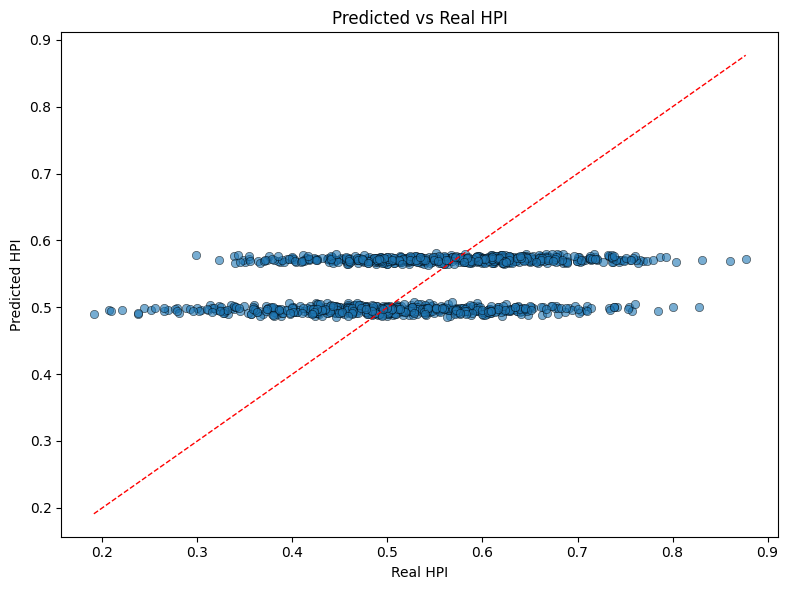

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression sklearn")
print(f"R2 test: {r2:.4f}")
print(f"MSE test: {mse:.4f}")
print(f"RMSE test: {rmse:.4f}")
print(f"MAE test: {mae:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="black", linewidth=0.5)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=1)
plt.xlabel("Real HPI")
plt.ylabel("Predicted HPI")
plt.title("Predicted vs Real HPI")
plt.tight_layout()
plt.show()

## Correlación Spearman - Públicos

In [13]:
publicos = df[df["sector"] == "Public"].copy()

In [14]:
numeric_cols = publicos.select_dtypes(include=[np.number]).columns.drop(exclude_vars)

results = []
for col in numeric_cols:
    corr, p_value = spearmanr(publicos[col], publicos[target_col])
    results.append({
        "variable": col,
        "spearman_corr": corr,
        "p_value": p_value,
        "significant": p_value < 0.1
    })

topvars_pub = (
    pd.DataFrame(results)
      .sort_values(by="spearman_corr", key=lambda x: x.abs(), ascending=False)
      .reset_index(drop=True)
)

print("Variables numéricas más correlacionadas con HPI en hospitales públicos (Spearman):")
topvars_pub.head(20)

Variables numéricas más correlacionadas con HPI en hospitales públicos (Spearman):


C:\Users\Estudio\AppData\Local\Temp\ipykernel_13684\2917328544.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(publicos[col], publicos[target_col])


,variable,spearman_corr,p_value,significant
0,doctor_patient_ratio,0.047222,0.012707,True
1,medical_equipment_score,-0.045273,0.016898,True
2,total_doctors,-0.036679,0.052976,True
3,icu_beds,-0.035269,0.062794,True
4,telemedicine_service_bin,-0.031511,0.096455,True
5,nurses,0.025364,0.180923,False
6,emergency_department_bin,0.021339,0.260347,False
7,ambulance_available_bin,-0.018365,0.332719,False
8,estimated_daily_load,0.017385,0.359180,False
9,daily_outpatients,0.017244,0.363083,False


In [15]:
selected_pub = topvars_pub[topvars_pub["significant"]]['variable'].tolist()
print("Variables numéricas más correlacionadas con HPI en hospitales públicos (significativas):")
selected_pub

Variables numéricas más correlacionadas con HPI en hospitales públicos (significativas):


['doctor_patient_ratio',
 'medical_equipment_score',
 'total_doctors',
 'icu_beds',
 'telemedicine_service_bin']

## Correlación Spearman - Privados

In [16]:
privados = df[df["sector"] == "Private"].copy()

In [17]:
numeric_cols = privados.select_dtypes(include=[np.number]).columns.drop(exclude_vars)

results = []
for col in numeric_cols:
    corr, p_value = spearmanr(privados[col], privados[target_col])
    results.append({
        "variable": col,
        "spearman_corr": corr,
        "p_value": p_value,
        "significant": p_value < 0.1
    })

topvars_pri = (
    pd.DataFrame(results)
      .sort_values(by="spearman_corr", key=lambda x: x.abs(), ascending=False)
      .reset_index(drop=True)
)

print("Variables numéricas más correlacionadas con HPI en hospitales privados (Spearman):")
topvars_pri.head(20)

Variables numéricas más correlacionadas con HPI en hospitales privados (Spearman):


C:\Users\Estudio\AppData\Local\Temp\ipykernel_13684\1662837948.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(privados[col], privados[target_col])


,variable,spearman_corr,p_value,significant
0,operation_theatres,-0.038395,0.045418,True
1,paramedical_staff,-0.037867,0.048467,True
2,estimated_daily_load,-0.037346,0.051647,True
3,daily_outpatients,-0.037216,0.052466,True
4,ambulance_available_bin,0.036413,0.057771,True
5,total_doctors,0.034620,0.071242,True
6,insurance_accepted_bin,-0.027590,0.150579,False
7,total_beds,0.025101,0.190956,False
8,consultation_fee,0.024430,0.203101,False
9,year,-0.022135,0.248836,False


In [18]:
selected_pri = topvars_pri[topvars_pri["significant"]]['variable'].tolist()
print("Variables numéricas más correlacionadas con HPI en hospitales privados (significativas):")
selected_pri

Variables numéricas más correlacionadas con HPI en hospitales privados (significativas):


['operation_theatres',
 'paramedical_staff',
 'estimated_daily_load',
 'daily_outpatients',
 'ambulance_available_bin',
 'total_doctors']

## Regresion lineal con step forwards-backwards 

In [19]:
import statsmodels.api as sm

def stepwise_selection(X, y, initial_list=None, threshold_in=0.1, threshold_out=0.1, verbose=True):
    if initial_list is None:
        included = []
    else:
        included = list(initial_list)

    while True:
        changed = False

        excluded = [col for col in X.columns if col not in included]
        new_pvalues = pd.Series(index=excluded, dtype=float)

        for col in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [col]])).fit()
            new_pvalues[col] = model.pvalues[col]

        if not new_pvalues.empty:
            best_pval = new_pvalues.min()
            if best_pval < threshold_in:
                best_feature = new_pvalues.idxmin()
                included.append(best_feature)
                changed = True
                if verbose:
                    print(f"Añadido {best_feature:30} p-value={best_pval:.6f}")

        if included:
            model = sm.OLS(y, sm.add_constant(X[included])).fit()
            pvalues = model.pvalues.iloc[1:]
            worst_pval = pvalues.max()
            if worst_pval > threshold_out:
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                changed = True
                if verbose:
                    print(f"Eliminado {worst_feature:28} p-value={worst_pval:.6f}")

        if not changed:
            break

    return included

### Full Dataset

In [21]:
X = df[selected_vars].copy()
y = df[target_col]

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("\nPaso forward/backward:")
best_features = stepwise_selection(X_scaled, y, initial_list=[])
print("\nVariables seleccionadas por stepwise:")
print(best_features)

final_model = sm.OLS(y, sm.add_constant(X_scaled[best_features])).fit()
print("\nModelo final con variables seleccionadas:")
print(final_model.summary())


Paso forward/backward:
Añadido sector_bin                     p-value=0.000000
Añadido medical_equipment_score        p-value=0.020196
Añadido doctor_patient_ratio           p-value=0.042799

Variables seleccionadas por stepwise:
['sector_bin', 'medical_equipment_score', 'doctor_patient_ratio']

Modelo final con variables seleccionadas:
                            OLS Regression Results                            
Dep. Variable:                    hpi   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     239.0
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          9.20e-146
Time:                        14:07:23   Log-Likelihood:                 4691.3
No. Observations:                5500   AIC:                            -9375.
Df Residuals:                    5496   BIC:                            -9348.
Df Model:                   

### Hospitales Públicos

In [22]:
X = publicos[selected_pub].copy()
y = publicos[target_col]

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("\nPaso forward/backward:")
best_features = stepwise_selection(X_scaled, y, initial_list=[])
print("\nVariables seleccionadas por stepwise:")
print(best_features)

final_model = sm.OLS(y, sm.add_constant(X_scaled[best_features])).fit()
print("\nModelo final con variables seleccionadas:")
print(final_model.summary())


Paso forward/backward:
Añadido doctor_patient_ratio           p-value=0.018898
Añadido medical_equipment_score        p-value=0.023550
Añadido icu_beds                       p-value=0.043859
Añadido telemedicine_service_bin       p-value=0.059742

Variables seleccionadas por stepwise:
['doctor_patient_ratio', 'medical_equipment_score', 'icu_beds', 'telemedicine_service_bin']

Modelo final con variables seleccionadas:
                            OLS Regression Results                            
Dep. Variable:                    hpi   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     4.574
Date:                Thu, 16 Apr 2026   Prob (F-statistic):            0.00111
Time:                        14:07:23   Log-Likelihood:                 2548.9
No. Observations:                2784   AIC:                            -5088.
Df Residuals:            

### Hospitales Privados

In [23]:
X = privados[selected_pri].copy()
y = privados[target_col]

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("\nPaso forward/backward:")
best_features = stepwise_selection(X_scaled, y, initial_list=[])
print("\nVariables seleccionadas por stepwise:")
print(best_features)

final_model = sm.OLS(y, sm.add_constant(X_scaled[best_features])).fit()
print("\nModelo final con variables seleccionadas:")
print(final_model.summary())


Paso forward/backward:
Añadido paramedical_staff              p-value=0.018508
Añadido total_doctors                  p-value=0.034961
Añadido operation_theatres             p-value=0.059590
Añadido ambulance_available_bin        p-value=0.096662
Añadido estimated_daily_load           p-value=0.099205

Variables seleccionadas por stepwise:
['paramedical_staff', 'total_doctors', 'operation_theatres', 'ambulance_available_bin', 'estimated_daily_load']

Modelo final con variables seleccionadas:
                            OLS Regression Results                            
Dep. Variable:                    hpi   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     3.815
Date:                Thu, 16 Apr 2026   Prob (F-statistic):            0.00191
Time:                        14:07:23   Log-Likelihood:                 2174.5
No. Observations:           

In [28]:
# Índice de desempeño hospitalario (HPI)
hpi_vars = ["hpi", 'mortality_rate', 'infection_rate', 'readmission_rate', 
            'patient_satisfaction_score', 'waiting_time_minutes', 
            'average_length_of_stay', 'average_treatment_cost', 
            'quality_score', 'efficiency_score', 'cost_score',
            'sector_bin', 'government_funding']

# Scores principales
quality_vars = ['quality_score', 'hpi', 
                'mortality_rate', 'infection_rate', 
                'readmission_rate', 'patient_satisfaction_score']

efficiency_vars = ['efficiency_score', 'hpi', 
                   'waiting_time_minutes', 'average_length_of_stay']

cost_vars = ['cost_score', 'hpi', 
             'average_treatment_cost']

# Variables específicas de cada métrica
# Calidad
mortality_vars = ['mortality_rate', 'hpi',
                  'quality_score']
infection_vars = ['infection_rate', 'hpi',
                  'quality_score']
readmission_vars = ['readmission_rate', 'hpi',
                    'quality_score']
satisfaction_vars = ['patient_satisfaction_score', 'hpi',
                     'quality_score']

# Eficiencia
waiting_time_vars = ['waiting_time_minutes', 'hpi',
                     'efficiency_score']
length_of_stay_vars = ['average_length_of_stay', 'hpi',
                       'efficiency_score']

# Costo
treatment_cost_vars = ['average_treatment_cost', 'hpi',
                       'cost_score']

# Variables relacionadas
daily_load_vars = ['estimated_daily_load', 'monthly_admissions', 'daily_outpatients']
daily_outpatients_vars = ['daily_outpatients', 'estimated_daily_load']

In [29]:
target_dict = {
    'hpi': hpi_vars,
    'quality_score': quality_vars,
    'efficiency_score': efficiency_vars,
    'cost_score': cost_vars,
    'mortality_rate': mortality_vars,
    'infection_rate': infection_vars,
    'readmission_rate': readmission_vars,
    'patient_satisfaction_score': satisfaction_vars,
    'waiting_time_minutes': waiting_time_vars,
    'average_length_of_stay': length_of_stay_vars,
    'average_treatment_cost': treatment_cost_vars,
    'estimated_daily_load': daily_load_vars,
    'daily_outpatients': daily_outpatients_vars
}
exclude = list(target_dict.keys()) + ['hpi']
for col in df.select_dtypes(include=[np.number]).columns.drop(exclude):
    target_dict[col] = [col]

In [34]:
Radj_values = {}
for target_col, exclude_vars in target_dict.items():
    print(f"\nAnalizando variable objetivo: {target_col.upper()}")
    numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(exclude_vars)
    
    results = []
    for col in numeric_cols:
        corr, p_value = spearmanr(df[col], df[target_col])
        results.append({
            "variable": col,
            "spearman_corr": corr,
            "p_value": p_value,
            "significant": p_value < 0.1
        })
    
    spearman_top = (
        pd.DataFrame(results)
          .sort_values(by="spearman_corr", key=lambda x: x.abs(), ascending=False)
          .reset_index(drop=True)
    )
    
    selected_vars = spearman_top[spearman_top["significant"]]['variable'].tolist()
    #print(f"Variables numéricas más correlacionadas con {target_col} (significativas):")
    #print(selected_vars)
    
    X = df[selected_vars].copy()
    y = df[target_col].copy()

    if selected_vars:
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(
            scaler.fit_transform(X),
            columns=X.columns,
            index=X.index
        )
    else: 
        print(f"No se encontraron variables significativas para {target_col}. Se usará el modelo con solo la constante.")
        X_scaled = pd.DataFrame(np.ones(len(df)), columns=['const'], index=df.index)

    #print("\nPaso forward/backward:")
    best_features = stepwise_selection(X_scaled, y, initial_list=[])
    #print("\nVariables seleccionadas por stepwise:")
    #print(best_features)
    
    final_model = sm.OLS(y, sm.add_constant(X_scaled[best_features])).fit()
    var_names = ["const"] + best_features
    coeficientes = {name: coef for name, coef in zip(var_names, final_model.params)}
    print("\nModelo final con variables seleccionadas:")
    print("\nParámetros: ")
    print(f'{"Variable":30} Coeficiente')
    for name, coef in coeficientes.items():
        print(f'{name:30} {coef:.4f}')
    print("\nR2: ", final_model.rsquared)
    Radj_values[target_col] = final_model.rsquared_adj


Analizando variable objetivo: HPI
Añadido consultation_fee               p-value=0.000000
Añadido surgery_cost                   p-value=0.000000
Añadido doctor_patient_ratio           p-value=0.035870
Añadido medical_equipment_score        p-value=0.049453

Modelo final con variables seleccionadas:

Parámetros: 
Variable                       Coeficiente
const                          0.5347
consultation_fee               -0.0196
surgery_cost                   -0.0146
doctor_patient_ratio           0.0030
medical_equipment_score        -0.0028

R2:  0.07699761170850417

Analizando variable objetivo: QUALITY_SCORE
Añadido diagnostic_labs_bin            p-value=0.011220
Añadido medical_equipment_score        p-value=0.018364
Añadido doctor_patient_ratio           p-value=0.057163

Modelo final con variables seleccionadas:

Parámetros: 
Variable                       Coeficiente
const                          0.5013
diagnostic_labs_bin            -0.0050
medical_equipment_score        -

In [35]:
pd.DataFrame(Radj_values.values(), index=Radj_values.keys(), columns=['R_adj']).sort_values('R_adj', ascending=False)

,R_adj
sector_bin,8.331745e-01
consultation_fee,6.146596e-01
government_funding,6.014251e-01
surgery_cost,4.988791e-01
cost_score,4.634057e-01
average_treatment_cost,4.633839e-01
icu_inconsistency_flag,1.409725e-01
total_beds,1.124562e-01
hpi,7.632573e-02
icu_beds,3.352122e-02
